# K-Armed-Bandit Experiment

The purpose of this notebook is to demonstrate the performance of the Thompson Sampling algorithm on a K-armed bandit problem. The K-armed bandit problem is a classic reinforcement learning problem where an agent must choose between K different actions (or arms) to maximize its reward.  

The agent does not know the expected reward of each action, and it must explore the actions to learn their expected rewards while also exploiting the best-known action to maximize its total reward.  

The agent's goal is to learn the expected reward of each action and select the action that maximizes the expected reward. The Thompson Sampling algorithm is a Bayesian approach to solving the K-armed bandit problem, where the agent maintains a probability distribution over the expected rewards of each action and samples from these distributions to select actions.  

For this experiment, we create 10 armed-bandits with normally distributed reward $\mathcal{N(q_{*}(a), 1)}$. Each $q_{*}(a)$ is sampled from a normal distribution $\mathcal{N(0, 1)}$.

In [1]:
from k_armed_bandit.bandits import OneArmedBandit, plot_average_rewards, plot_optimal_action_pct

# initialize the K-armed bandit problem
bandits = [OneArmedBandit.random_bandit() for _ in range(10)]

for b in bandits:
    print(f"Bandit: {b}, Mean: {b.mu}, Std: {b.sigma}")

Bandit: OneArmedBandit(mu=0.11, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: 0.11156570175138841, Std: 1.0
Bandit: OneArmedBandit(mu=-0.83, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: -0.8341205958042821, Std: 1.0
Bandit: OneArmedBandit(mu=1.46, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: 1.4584015054934474, Std: 1.0
Bandit: OneArmedBandit(mu=-0.89, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: -0.8855715267960633, Std: 1.0
Bandit: OneArmedBandit(mu=-0.85, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: -0.8514938909500438, Std: 1.0
Bandit: OneArmedBandit(mu=-0.14, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: -0.14334080871079158, Std: 1.0
Bandit: OneArmedBandit(mu=-2.11, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: -2.1098843867233197, Std: 1.0
Bandit: OneArmedBandit(mu=0.92, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: 0.9235784947954092, Std: 1.0
Bandit: OneArmedBandit(mu=0.07, sigma=1.00, n=0, q=0.00, learning_rate=None), Mean: 

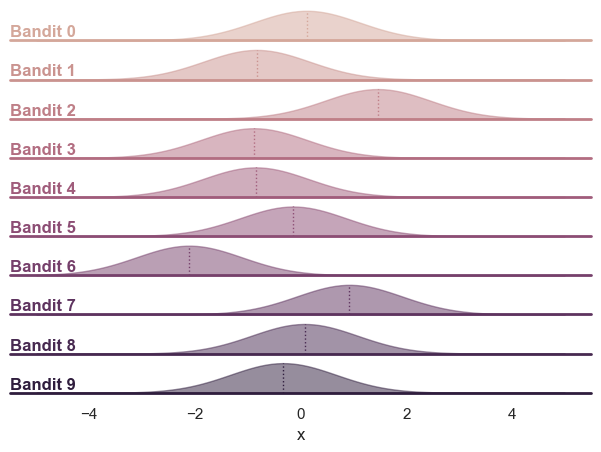

In [2]:
# create a plot of each bandit reward distribution
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
warnings.filterwarnings('ignore', category=UserWarning)

N_POINTS = 100
X_LIM = (-5, 5)

# Create the data
x = np.array([])
y = np.array([])
g = np.array([])
x_bandit = np.append(x, np.linspace(X_LIM[0], X_LIM[1], N_POINTS))


for i, bandit in enumerate(bandits):
    mu = bandit.mu
    sigma = 1
    # sample N_POINTS points from the normal distribution
    x = np.append(x, x_bandit)
    y = np.append(y, stats.norm.pdf(x_bandit, mu, sigma))
    g = np.append(g, [i] * N_POINTS)

df = pd.DataFrame(dict(x=x, g=g, y=y))

df["g"] = df["g"].apply(lambda x: f"Bandit {x:.0f}")

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=0.5, light=.7)
g = sns.FacetGrid(df, row="g", hue="g", aspect=15, height=0.5, palette=pal)


# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Fill the area under the curve
g.map(plt.fill_between, "x", "y", alpha=.5, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .3, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

# Add a vertical line at the mean for each bandit's own facet only, using the actual y maximum for that bandit
for i, bandit in enumerate(bandits):
    ax = g.facet_axis(i, 0)
    # Find the y value at the mean for this bandit
    y_mean = stats.norm.pdf(bandit.mu, bandit.mu, 1)
    ax.vlines(bandit.mu, 0, y_mean, color=pal[i], lw=1, linestyle="dotted")

g.map(label, "x")

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True);

The above figure shows the true reward distribution of each arm.

Let's now run a single experiment with our 10 armed-bandits. We will use the epsilon-greedy algorithm with $\epsilon = 0.1$ and a learning rate of $\alpha = 0.1$. The agent will select an arm to pull, receive a reward, and update its estimate of the expected reward for that arm.

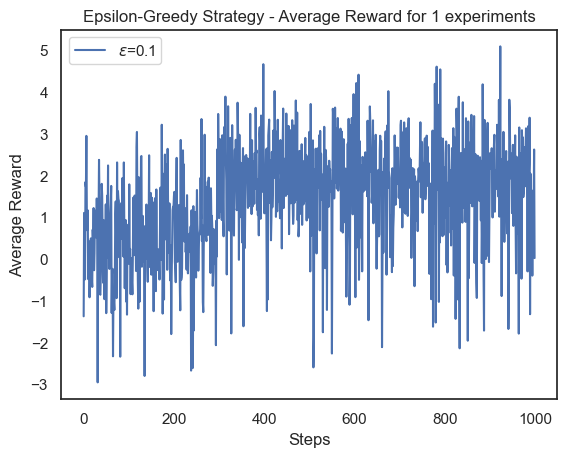

In [7]:
from k_armed_bandit.bandits import run_experiments

# run a single experiment
epsilons = [0.1]
rewards = run_experiments(
    k=10,
    epsilons= [0.1],
    n_actions=1_000,
    n_experiments=1,
    optimist_initial_value = 0,
    learning_rate= 0.1,
)

plot_average_rewards(rewards)

As we can see, the reward distribution is fairly noisy. In order to mitigate for the noise, we will run the experiment 2,000 times and plot the average reward for each action.

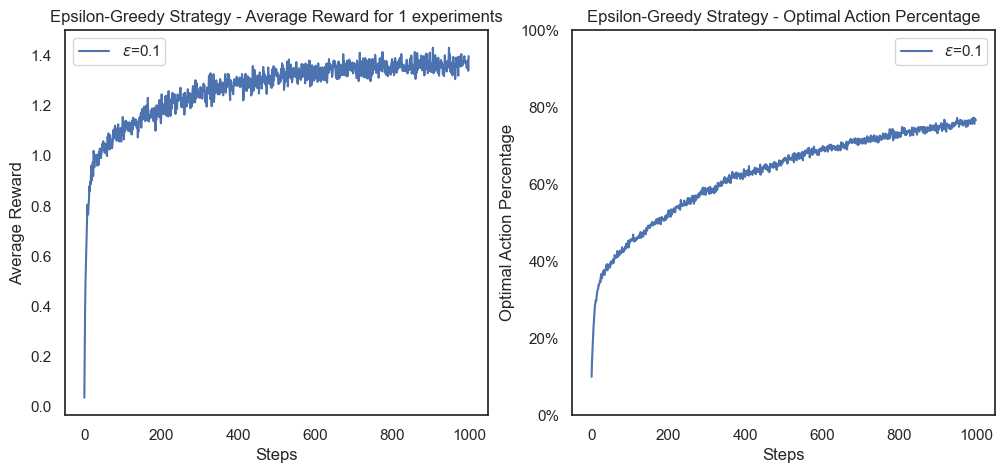

In [9]:
epsilons = [0.1]
rewards = run_experiments(
    k=10,
    epsilons= [0.1],
    n_actions=1_000,
    n_experiments=2_000,
    optimist_initial_value = 0,
    learning_rate= 0.1,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_average_rewards(rewards, ax=axes[0])
plot_optimal_action_pct(rewards, ax=axes[1])
plt.show()

In [12]:
epsilons = [0.01, 0.1, 0.2]
rewards = run_experiments(
    k=10,
    epsilons= epsilons,
    n_actions=1_000,
    n_experiments=2_000,
    optimist_initial_value = 0,
    learning_rate= 0.1,
)

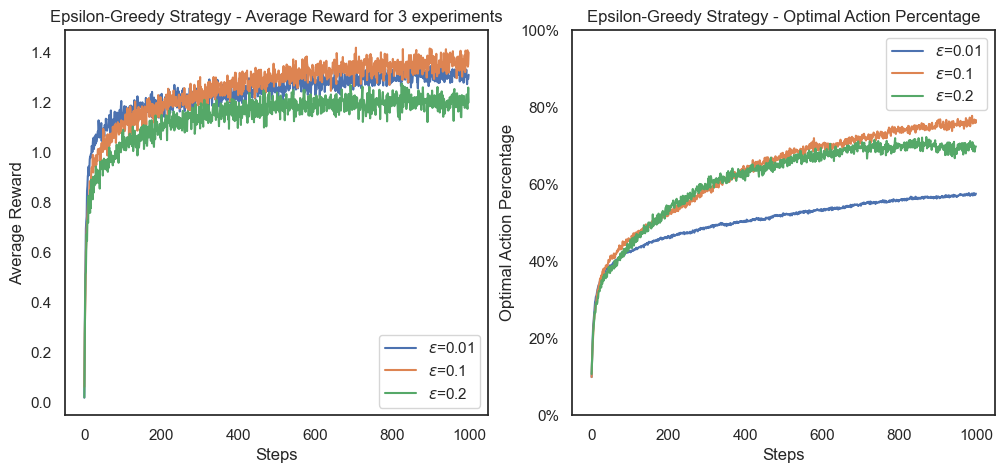

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_average_rewards(rewards, ax=axes[0])
plot_optimal_action_pct(rewards, ax=axes[1])
plt.show()